# SuppFig — Sample QC: molecular time and signature exposures
Per-sample HRD / WGD molecular time (top) and SBS1 / SBS3 exposures split by Early / Late / Undefined molecular time, across SCANB, PCAWG and INFORM breast HRD-WGD cancers.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import gridspec

import matplotlib as mpl
mpl.rcParams.update({
    "pdf.fonttype": 42, "ps.fonttype": 42, "font.family": "sans-serif", "font.size": 9,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.linewidth": 0.25,
    "xtick.major.width": 0.25, "ytick.major.width": 0.25,
    "xtick.minor.width": 0.25, "ytick.minor.width": 0.25,
    "xtick.labelsize": 7, "ytick.labelsize": 7,
})

def nature_axes(ax, keep_top=False):
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(keep_top)
    for sp in ax.spines.values():
        sp.set_linewidth(0.25)
    ax.tick_params(width=0.25)
    return ax

TIMING = {
    'SCANB': '../../data/output/May27_TimingRun/SCANB_Breast_WGD_HRD_TimingResults_timing_nboot200_0001_only_prob_change_boot_pSub.csv',
    'PCAWG': '../../data/output/May27_TimingRun/PCAWG_Breast_WGD_HRD_TimingResults_timing_nboot200_0001_only_prob_change_boot_pSub.csv',
    'INFORM': '../../data/output/May27_TimingRun/INFORM_Breast_WGD_HRD_TimingResults_timing_nboot200_0001_only_prob_change_boot_pSub.csv',
}
EXPOSURES = '../../data/output/SuppFig7_exposure_summary.csv'
METADATA = '../../data/metadata/pan_metadata_v5.csv'
OUT_DIR = '../output/SuppFig_QC_molecularTime_exposures'
os.makedirs(OUT_DIR, exist_ok=True)

In [2]:
EXCLUDE = {
    'PD31145a', 'PD35929a', 'PD36006a', 'PD35926a', 'PD35935a', 'PD36067a', 'PD35990a',
    'PD31129a', 'PD31155a', 'PD35941a', 'PD36024a', 'PD31044a', 'PD31171a', 'PD31178a',
    'PD36054a', 'PD31056a',
    '7456abd5-303e-4e6f-bf4e-47efefc7310f', 'fc806c50-2f6e-418d-e040-11ac0d485f01',
    '5dbf3203-ce73-41e4-bf9a-32fc856f73f5', '418e916b-7a4e-4fab-8616-15dcec4d79f8',
    'f393bb07-270c-2c93-e040-11ac0d484533', 'b752b444-f033-4be4-9d24-e5e80b4181af',
    '207f8a42-5b05-4876-b0ae-ebfaeea27844', 'd5372745-95cf-4572-a6e7-e7f5b796911a',
    'f393bb0c-4178-ca4a-e040-11ac0d48455f', '987528ac-437a-4eb8-a335-4f2076d5c006',
    'fc8130df-8ec8-5b1e-e040-11ac0d485e06', 'fca6150f-d555-a29e-e040-11ac0d4873b2',
    '43f7a2e0-fec9-4e43-872d-18c6c946fa17', 'Patient33', 'Patient101',
}
display_map = pd.read_csv(METADATA).set_index('sample')['sample.display'].to_dict()

In [3]:
timing_cols = ['ID', 'HRDTime', 'HRDTime_ci_lo', 'HRDTime_ci_hi',
               'HRDTime_ci_IQR_lo', 'HRDTime_ci_IQR_hi',
               'WGDTime', 'WGDTime_ci_lo', 'WGDTime_ci_hi',
               'WGDTime_ci_IQR_lo', 'WGDTime_ci_IQR_hi']

x_pos = 0
boundaries = []
parts = []
order = []
for cohort, f in TIMING.items():
    df = pd.read_csv(f)[timing_cols].dropna()
    valid = (df[[c for c in timing_cols if c != 'ID']] >= 0).all(axis=1)
    df = df[valid].copy()
    df['ci_width'] = df['HRDTime_ci_lo'] + df['HRDTime_ci_hi']
    df = df.sort_values('ci_width').reset_index(drop=True)
    df['Cohort'] = cohort
    df['x'] = range(x_pos, x_pos + len(df))
    x_pos += len(df)
    boundaries.append(x_pos)
    order += df['ID'].tolist()
    parts.append(df)
tdf = pd.concat(parts, ignore_index=True)
xpos = dict(zip(tdf['ID'], tdf['x']))

In [4]:
exp = pd.read_csv(EXPOSURES)
exp['Period'] = exp['Period'].fillna('NA')
exp = exp[exp['Sample'].isin(xpos)].copy()
exp['x'] = exp['Sample'].map(xpos)

SIG_COLOR = {'SBS1': '#4e79b0', 'SBS3': '#f2a93b'}
PERIODS = ['Early', 'Late', 'NA']
PERIOD_LABEL = {'Early': 'Early', 'Late': 'Late', 'NA': 'Undefined (NA)'}

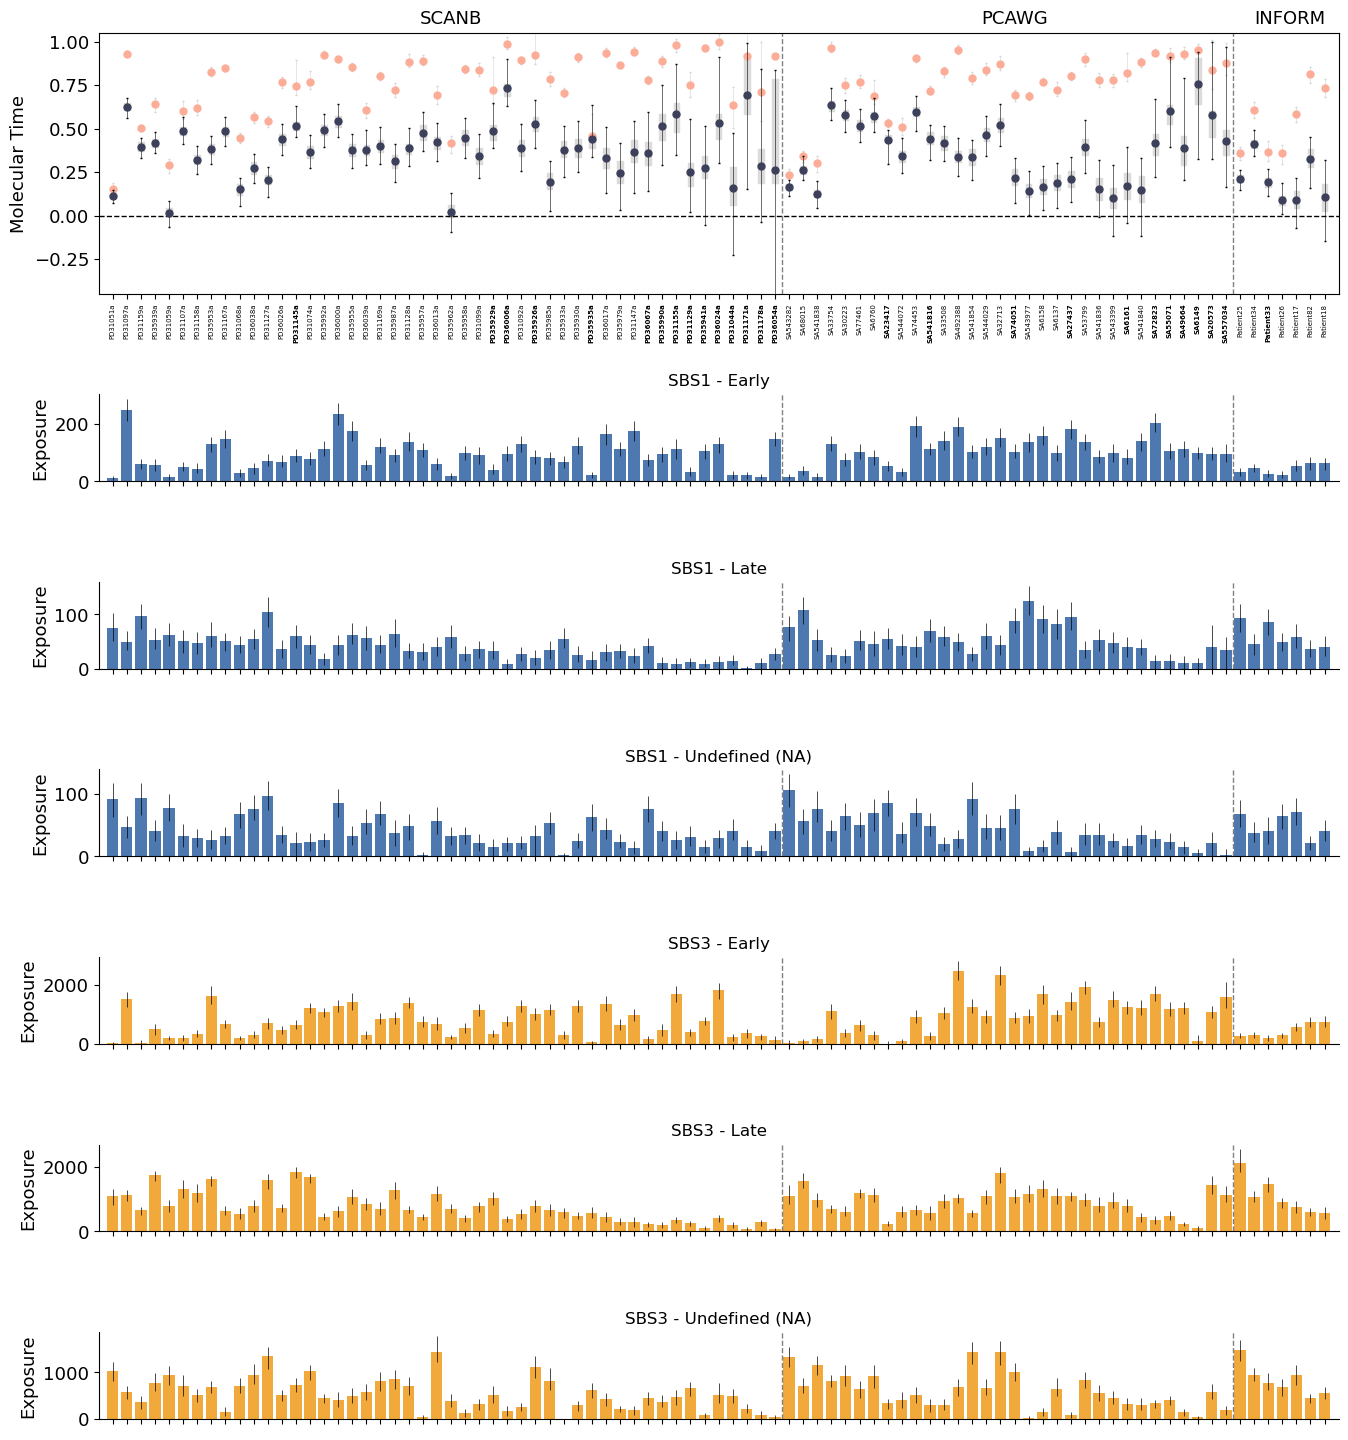

In [5]:
fig = plt.figure(figsize=(16, 18))
gs = gridspec.GridSpec(7, 1, height_ratios=[3, 1, 1, 1, 1, 1, 1], hspace=0.9)
ax_top = fig.add_subplot(gs[0])

for cohort, g in tdf.groupby('Cohort'):
    for _, row in g.iterrows():
        ax_top.fill_between([row['x'] - 0.2, row['x'] + 0.2],
                            row['HRDTime'] - row['HRDTime_ci_IQR_lo'],
                            row['HRDTime'] + row['HRDTime_ci_IQR_hi'],
                            color='#dbdbdb', zorder=0)
    ax_top.errorbar(g['x'], g['WGDTime'],
                    yerr=[g['WGDTime_ci_lo'], g['WGDTime_ci_hi']],
                    fmt='o', ms=5, color='#fcad97', ecolor='lightgrey',
                    elinewidth=0.4, capsize=1, zorder=2)
    ax_top.errorbar(g['x'], g['HRDTime'],
                    yerr=[g['HRDTime_ci_lo'], g['HRDTime_ci_hi']],
                    fmt='o', ms=5, color='#3d405b', ecolor='k',
                    elinewidth=0.4, capsize=1, zorder=3)
ax_top.axhline(0, color='k', ls='--', lw=1)
for b in boundaries[:-1]:
    ax_top.axvline(b - 0.5, color='grey', ls='--', lw=1)
ax_top.set_ylim(-0.45, 1.05)
ax_top.set_ylabel('Molecular Time')
nature_axes(ax_top)
ax_top.set_xlim(-1, len(tdf))
labels = [display_map.get(s, s) for s in order]
ax_top.set_xticks(range(len(order)))
ax_top.set_xticklabels(labels, rotation=90, fontsize=5)
for tick, sid in zip(ax_top.get_xticklabels(), order):
    if sid in EXCLUDE:
        tick.set_fontweight('bold')
mids = [np.mean([([0] + boundaries)[i], boundaries[i]]) for i in range(3)]
for m, name in zip(mids, TIMING):
    ax_top.text(m, 1.08, name, ha='center', va='bottom', fontsize=9, fontweight='bold')

row_i = 1
for sig in ['SBS1', 'SBS3']:
    for period in PERIODS:
        ax = fig.add_subplot(gs[row_i], sharex=ax_top)
        sub = exp[(exp['Signature'] == sig) & (exp['Period'] == period)]
        ax.bar(sub['x'], sub['Mean'], color=SIG_COLOR[sig], width=0.8)
        ax.errorbar(sub['x'], sub['Mean'],
                    yerr=[sub['Mean'] - sub['Lower'], sub['Upper'] - sub['Mean']],
                    fmt='none', ecolor='k', elinewidth=0.5, capsize=0)
        for b in boundaries[:-1]:
            ax.axvline(b - 0.5, color='grey', ls='--', lw=1)
        ax.set_ylabel('Exposure')
        ax.set_title(f'{sig} - {PERIOD_LABEL[period]}', fontsize=8)
        nature_axes(ax)
        plt.setp(ax.get_xticklabels(), visible=False)
        row_i += 1

fig.savefig(f'{OUT_DIR}/SuppFig_QC_molecularTime_exposures.pdf', bbox_inches='tight')
plt.show()